## Introduction
From the previous SVD analysis, we estimated that the number of chemical species was 3. But, as we mentioned before, SVD provides purely mathematical components. To recover chemically meaningful spectra and their corresponding concentration profiles, we now apply **Multivariate Curve Resolution (MCR)**

### MCR
As we mentioned before, MCR is a chemometric technique that decomposes complex, overlapping mixture data into individual, "pure" components.

It typically utilizes the MCR-Alternating Least Squares (MCR-ALS) algorithm to decompose the data matrix into 2 physically interpretable matrices:

$D \approx CS^T$

where,
* D is the data matrix
* C contains the concentration profiles of the chemical species over time
* S contains the pure components' spectra

In general, MCR solutions are not unique, since they are affected by rotational ambiguity. 
The use of chemically meaningful constraints and reasonable initial estimates helps guide the algorithm toward physically interpretable solutions.
The most common constraints are:
* **Non-neativity:** Forces concentrations and spectra to take only non-negative values.
* **Equality/Known-Value Constraints:** Fixes specific concentration or spectral values, or sets values to zero in known locations, forcing the solution to match known physical-chemical data.
* **Closure (Mass Balance):** Requires the concentration profiles of species in a reaction to sum to a constant value, ideal for closed systems.
* **Unimodality:** Ensures that concentration profiles show only one peak (a single maximum).

Because MCR-ALS solutions are not mathematically unique, the application of these chemically meaningful constraints is essential to obtain physically interpretable results.

## Library
We are will use the pyMCR library. Below is the link to their code and the documentation:

https://github.com/usnistgov/pyMCR

https://pages.nist.gov/pyMCR/

## Loading data
If you don't have the pyMCR already installed, you can remove the hash in the first line

In [1]:
# pip install pyMCR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pymcr
from pymcr.mcr import McrAR
from pymcr.regressors import OLS, NNLS
from pymcr.constraints import Constraint, ConstraintNonneg, ConstraintNorm
from pymcr.metrics import mse
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import curve_fit



# load spectra
holo = pd.read_csv('../data/1D_holo_spectrum.csv', index_col=0)
intermediate = pd.read_csv('../data/1D_intermediate_spectrum.csv', index_col=0)
apo = pd.read_csv('../data/1D_apo_spectrum.csv', index_col=0)

# load spectra
dataset = np.load("../data/dataset_1D.npz")

data = dataset["D"]
H_ppm = dataset["ppm"]
time_points = dataset["time_points"]

# MCR

We have 2 options for the estimates to use in the MCR:

**Spectra estimates:** We are going to use the spectra at the 1st, 5th, and the last time point as the estimates for the holo, intermediate, and apo spectra, respectively.

**Concentration estimates:** We are gonna use the SVD concentration profiles as estimates.

### pyMCR possible setups
The pyMCR library has 5 possible methods to run the iteration:

1. MCR-ALS: Alternating Least Squares, set'OLS' for S(st_regr) y C(c_regr).
2. MCR-NNLS: Non-Negative Least-Squares, set'NNLS' for S and C.
3. MCR-Gauss: 'MCR-NNLS' with the additional restriction of Gaussian signals and a baseline.
4. MCR-Ridge: S resolved via ridge (Ridge function from sklearn) and C via 'OLS'.
5. MCR-Lasso: S resolved via OLS and C via positive (Lasso function from skearn).

Possible restrictions that can be set:
1. Non-negativity:  `ConstraintNonneg`
2. Normalization (sum-to-one):  `ConstraintNorm`
3. Zero end-points: `ConstraintZeroEndPoints`
4. Zero (approx) end-points of cumulative summation (can specify nodes as well):  `ConstraintZeroCumSumEndPoints`
5. Non-negativity of cumulative summation:  `ConstraintCumsumNonneg`
6. Compress or cut values above or below a threshold value: `ConstraintCutBelow, ConstraintCutAbove, ConstraintCompressBelow, ConstraintCompressAbove`
7. Replace sum-across-features samples (e.g., 0 concentration) with prescribed target: `ConstraintReplaceZeros`
8. Enforce a plane ("planarize"). E.g., a concentration image is a plane:  `ConstraintPlanarize`

## Estimates: spectra

In [4]:
# Remember that components are selected based on inspection of singular values and temporal structure.
components = [0, 4, -1]
estimated_spetra = np.stack([data[i] for i in components])

mcr = McrAR(max_iter=500, tol_increase=4, c_regr='OLS',
                st_regr='OLS', c_constraints=[ConstraintNonneg(), ConstraintNorm()])
# Included a non-negativity constraint because this type of spectra do not present a negative signal
#Included Sum-to-1 constraint (ConstraintNorm()), which imposes that after each iteration
# the summation of all concentrations for each data point sums-to-one.
mcr.fit(data, ST=estimated_spetra, verbose=False)
print('\nFinal MSE: {:.7e}'.format(mcr.err[-1]))

C = mcr.C_
ST = mcr.ST_

Max iterations reached (500).

Final MSE: 1.6910691e-05


### Components' Spectra
The spectra obtained look very similar to the synthetic original data. The spectrum that shows the largest differences is, as expected, the intermediate one.

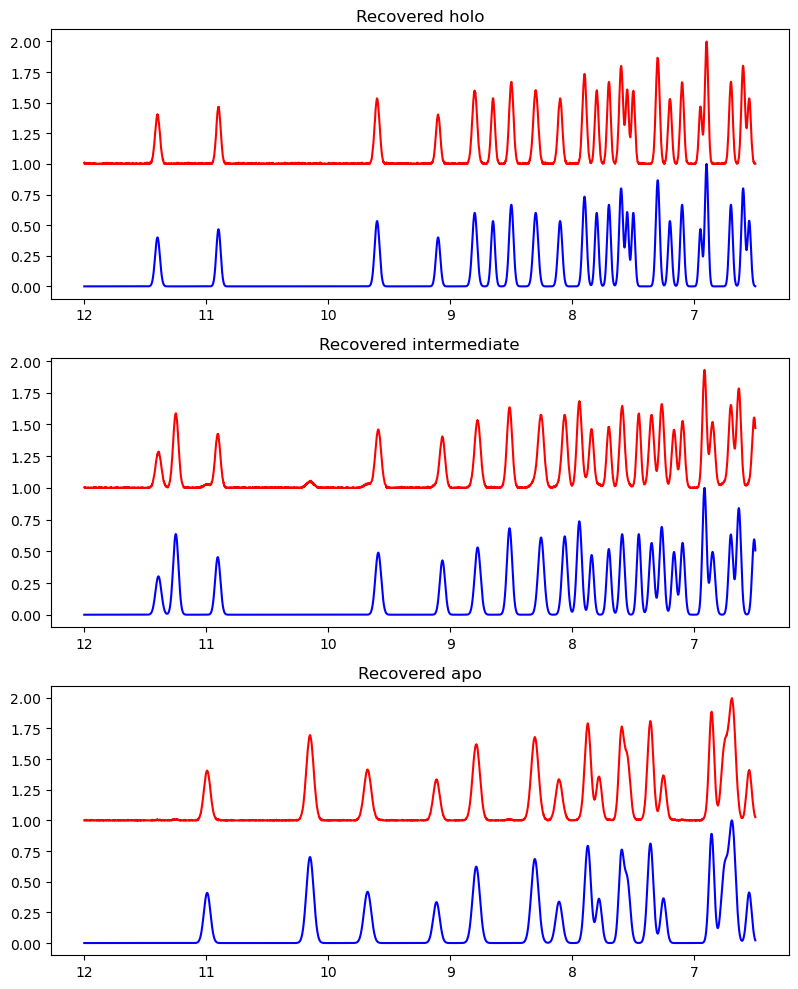

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

titles = [
    ("Original holo", "Recovered holo"),
    ("Original intermediate", "Recovered intermediate"),
    ("Original apo", "Recovered apo")
]

originals = [holo, intermediate, apo]
recovered = [ST.T[:,0], ST.T[:,1], ST.T[:,2]]

for i in range(3):
    axes[i].plot(H_ppm,
        originals[i],
        color='blue'
    )

    axes[i].plot(H_ppm,
        recovered[i]+1,
        color='red'
    )

    axes[i].set_title(titles[i][0])
    axes[i].set_title(titles[i][1])
    axes[i].invert_xaxis()


plt.tight_layout()
plt.show()

### Concentration Profiles

We can see how the concentration profile aligns with the kinetic demetallation process modeled when creating the synthetic dataset.

Text(0.5, 1.0, 'MCR-ALS Retrieved')

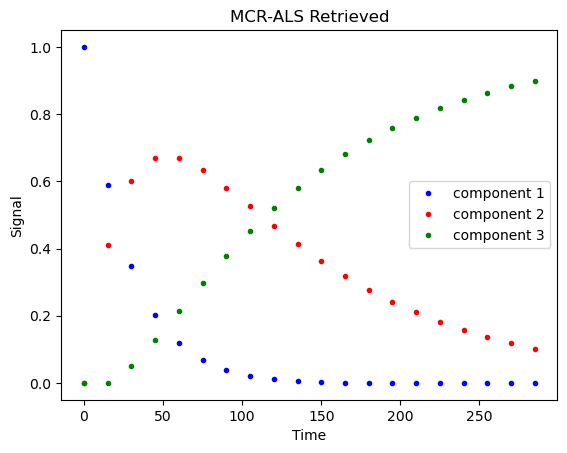

In [8]:
plt.plot(time_points, C.T[0,:], '.b', label="component 1")
plt.plot(time_points, C.T[1,:], '.r', label="component 2")
plt.plot(time_points, C.T[2,:], '.g', label="component 3")
plt.legend()
plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('MCR-ALS Retrieved')

## Estimates: concentration profile
Let us first return to the SVD concentration profiles.

Text(0.5, 0.98, 'SVD concentration profiles')

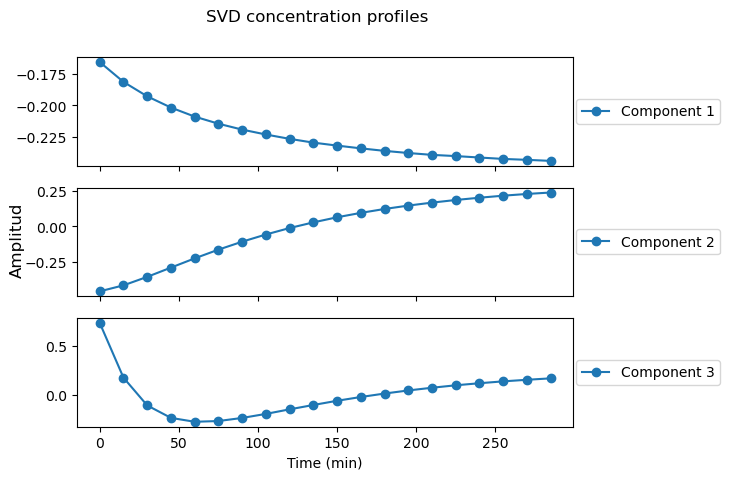

In [10]:
U,s,Vt=np.linalg.svd(data, full_matrices=False)
nComp = 3
fig, axes = plt.subplots(nComp, 1, sharex=True)

for i in range(nComp):
    axes[i].plot(time_points, U[:, i], "o-",
                 label=f"Component {i+1}")
    axes[i].legend(loc='center right', bbox_to_anchor=(1.31, 0.5))

axes[-1].set_xlabel("Time (min)")
fig.supylabel("Amplitud")
fig.suptitle("SVD concentration profiles")

This method is a bit tricky. To use the SVD concentration profile as estimate, we first need to normalize it. As you can see in the plot, and as we mentioned before, these concentrations can even present negative values. We also don't know which component corresponds to which species.

We can also notice that almost all concentrations are negative, and that the component that might be associated with the intermediate presents a minimum instead of a maximum, as expected for this kinetic process.

So, first, we are gonna mirror the concentration curves, and then we are gonna normalize so they look similar to a species concentration profile

In [12]:
U_norm = []
for i in range(3):
    U_norm.append(U[:, i]*(-1))

scaler = MinMaxScaler()
U_norm = scaler.fit_transform(np.array(U_norm).T)

In [13]:
mcr = McrAR(max_iter=500, tol_increase=4, c_regr='OLS',
                st_regr='OLS', c_constraints=[ConstraintNonneg(), ConstraintNorm()])
# Included a non-negativity constraint because this type of spectra do not present a negative signal
#Included Sum-to-1 constraint (ConstraintNorm()), which imposes that after each iteration
# the summation of all concentrations for each data point sums-to-one.
mcr.fit(data, C=U_norm, verbose=False)
print('\nFinal MSE: {:.7e}'.format(mcr.err[-1]))

C_2 = mcr.C_
ST_2 = mcr.ST_

Half-iterated 11 times since min error. Exiting.

Final MSE: 1.6905610e-05


### Results
First, we need to visualize the concentration profiles to understand which component corresponds to which species.

As we can see below, the first component corresponds to the third species, the second component to the first species, and the third component to the second species.

Again, the retrieved spectra are very similar to the original ones.

Text(0.5, 1.0, 'MCR-ALS Retrieved')

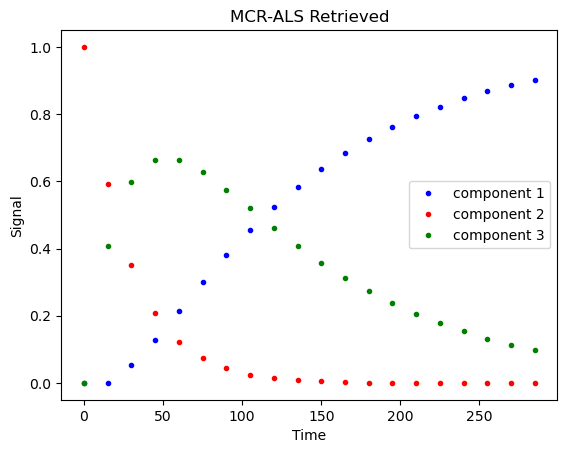

In [15]:
plt.plot(time_points, C_2.T[0,:], '.b', label="component 1")
plt.plot(time_points, C_2.T[1,:], '.r', label="component 2")
plt.plot(time_points, C_2.T[2,:], '.g', label="component 3")
plt.legend()
plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('MCR-ALS Retrieved')

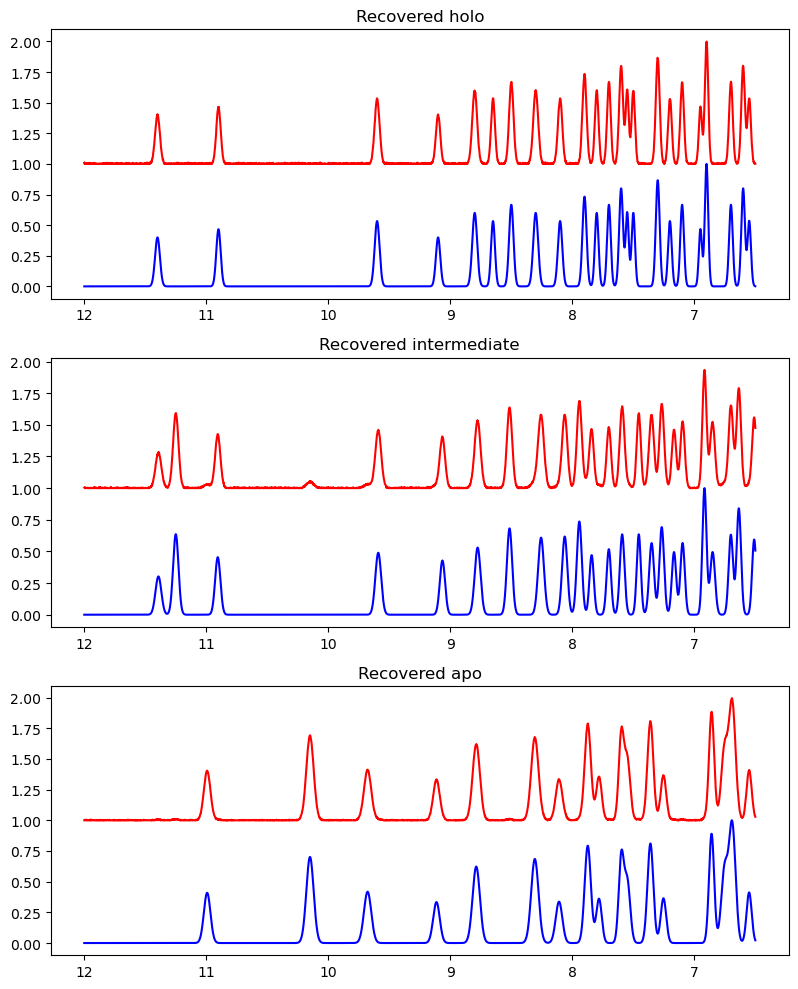

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

titles = [
    ("Original holo", "Recovered holo"),
    ("Original intermediate", "Recovered intermediate"),
    ("Original apo", "Recovered apo")
]

originals = [holo, intermediate, apo]
recovered = [ST_2.T[:,1], ST_2.T[:,2], ST_2.T[:,0]]

for i in range(3):
    axes[i].plot(H_ppm,
        originals[i],
        color='blue')

    axes[i].plot(H_ppm,
        recovered[i]+1,
        color='red')

    axes[i].set_title(titles[i][0])
    axes[i].set_title(titles[i][1])
    axes[i].invert_xaxis()


plt.tight_layout()
plt.show()

# Kinetic analysis

In [18]:
def curveA(t,k1,A0):
  y = A0*(np.exp(-k1*t))
  return y

def curveB(t,k1,k2,A0):
  y = ((k1*A0)/(k2-k1))*(np.exp(-k1*t)-np.exp(-k2*t))
  return y

def curveC(t,k1,k2,A0):
  y = A0*(1-(1/(k2-k1))*(k2*np.exp(-k1*t)-k1*np.exp(-k2*t)))
  return y

starting_k1 = (C.T[0,0]-C.T[0,1])/time_points[1]
starting_k2 = -(C.T[2,4]-C.T[2,5])/(time_points[5]-time_points[4])
fittedA, pcovA = curve_fit(curveA, time_points, C.T[0,:], [starting_k1, 1])
fittedB, pcovB = curve_fit(curveB, time_points, C.T[1,:], [starting_k1, starting_k2, 1])
fittedC, pcovC = curve_fit(curveC, time_points, C.T[2,:], [starting_k1, starting_k2, 1])

In [19]:
print(f'''
k1 from component 1: {fittedA[0]:.3f}, error: {np.sqrt(np.diag(pcovA))[0]:.4f}
k1 from component 2: {fittedB[0]:.3f}, error: {np.sqrt(np.diag(pcovB))[0]:.4f}
k1 from component 2: {fittedC[0]:.3f}, error: {np.sqrt(np.diag(pcovB))[0]:.4f}''')


k1 from component 1: 0.036, error: 0.0001
k1 from component 2: 0.034, error: 0.0002
k1 from component 2: 0.015, error: 0.0002


In [20]:
print(f'''
k2 from component 2: {fittedB[1]:.3f}, error: {np.sqrt(np.diag(pcovB))[1]:.4f}
k2 from component 2: {fittedC[1]:.3f}, error: {np.sqrt(np.diag(pcovB))[1]:.4f}''')


k2 from component 2: 0.009, error: 0.0000
k2 from component 2: 0.015, error: 0.0000


In [21]:
holo_fitted = curveA(time_points, fittedA[0], fittedA[1])
int_fitted = curveB(time_points, fittedB[0], fittedB[1], fittedB[2])
apo_fitted = curveC(time_points, fittedC[0], fittedC[1], fittedC[2])

Text(0.5, 1.0, 'Fit to kinetic equation')

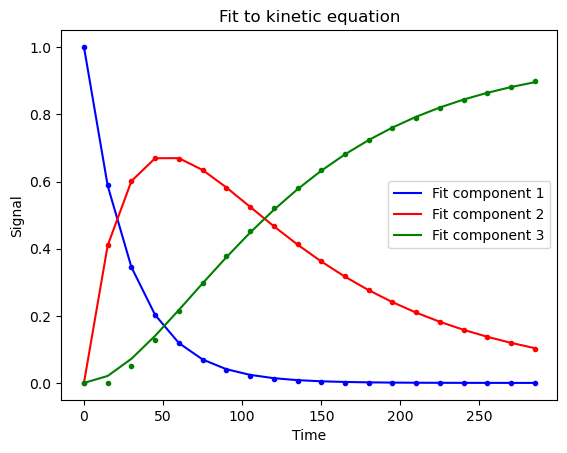

In [22]:
plt.plot(time_points, C.T[0,:], '.b')
plt.plot(time_points, holo_fitted, "-b", label = 'Fit component 1')
plt.plot(time_points, C.T[1,:], '.r')
plt.plot(time_points, int_fitted, "-r", label = 'Fit component 2')
plt.plot(time_points, C.T[2,:], '.g')
plt.plot(time_points, apo_fitted, "-g", label = 'Fit component 3')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('Fit to kinetic equation')

Text(0.5, 1.0, 'Residuals plot')

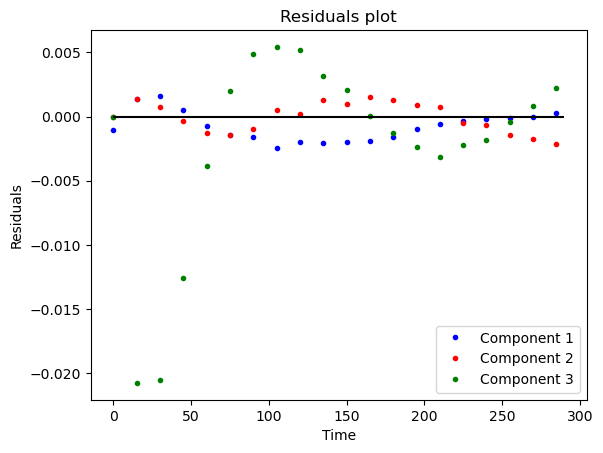

In [23]:
plt.plot(time_points, C.T[0,:]-holo_fitted, '.b', label = 'Component 1')
plt.plot(time_points, C.T[1,:]-int_fitted, ".r", label = 'Component 2')
plt.plot(time_points, C.T[2,:]-apo_fitted, ".g", label = 'Component 3')
plt.hlines(0, 0, 290, colors='black')
plt.legend()
plt.xlabel('Time')
plt.ylabel("Residuals")
plt.title("Residuals plot")

The fittings for components 1 and 2 recover values very close to the true kinetic constants. However, the fitting of the third component does not reproduce the expected parameter as accurately.

Although the overall fitting error is small, inspection of the residuals shows that the discrepancies are mainly concentrated at the first time points. At these early stages of the reaction, the concentration of the apo species is very low, since it is formed only after the intermediate accumulates.

When the signal intensity is close to the noise level, even small fluctuations can lead to relatively large errors in the estimated concentration profile. As a consequence, the kinetic fit of this component becomes more sensitive to noise and small deviations, which can bias the estimated parameter despite the overall good agreement of the model.